```{raw} html
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

(scalar_dynam)=
# 一维动力学

## 概述

在经济学中，许多变量依赖于它们的过去值。

例如，我们有理由相信去年的通货膨胀会影响今年的通货膨胀。
（比如去年的高通胀会导致人们要求更高的工资作为补偿，导致今年的价格进一步上涨。）

用$\pi_t$表示今年的通货膨胀率，$\pi_{t-1}$表示去年的通货膨胀率，我们可以用一般形式将这种关系写成：

$$ \pi_t = f(\pi_{t-1}) $$

其中$f$是描述变量之间关系的某个函数。

这个方程是一维离散时间动力系统的典型例子。

在本讲中，我们将探讨一维离散时间动力学的基本原理。

（虽然大多数量化模型通常包含两个或更多状态变量，但一维框架为我们理解基础理论和掌握核心概念提供了绝佳的起点。）

让我们从一些标准导入开始：

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## 一些定义

本节将介绍我们要研究的对象和关键概念。

### 函数组合

在本讲中你应该了解以下内容。

如果

* $g$ 是从集合 $A$ 到集合 $B$ 的函数，且
* $f$ 是从集合 $B$ 到集合 $C$ 的函数

那么 $f$ 和 $g$ 的**组合** $f \circ g$ 定义为

$$ 
    (f \circ g)(x) = f(g(x))
$$

举个简单的例子，如果

* $A=B=C=\mathbb R$（实数集）
* $g(x)=x^2$ 且 $f(x)=\sqrt{x}$

那么 $(f \circ g)(x) = \sqrt{x^2} = |x|$

如果 $f$ 是从 $A$ 到自身的函数，那么 $f^2$ 表示 $f$ 与自身的组合。

例如，当 $A = (0, \infty)$（正实数集）且 $f(x) = \sqrt{x}$ 时，我们有

$$
    f^2(x) = \sqrt{\sqrt{x}} = x^{1/4}
$$

类似地，如果 $n$ 是正整数，那么 $f^n$ 表示 $f$ 与自身的 $n$ 次组合。

在上面的例子中，$f^n(x) = x^{1/(2^n)}$。

### 动态系统

**（离散时间）动态系统**由一个集合 $S$ 和一个将 $S$ 映射到自身的函数 $g$ 组成。

动态系统的例子包括：

* $S = (0, 1)$ 且 $g(x) = \sqrt{x}$

* $S = (0, 1)$ 且 $g(x) = x^2$

* $S = \mathbb Z$（整数集）且 $g(x) = 2 x$

如果 $S = (-1, 1)$ 且 $g(x) = x+1$，那么 $S$ 和 $g$ 不构成动态系统，因为 $g(1) = 2$。

* 即 $g$ 并不总是将 $S$ 中的点映射回 $S$。

研究动态系统的重要性在于我们可以用它们来研究动态过程！

给定由集合 $S$ 和函数 $g$ 组成的动态系统，我们可以通过设定

```{math}
:label: sdsod

    x_{t+1} = g(x_t)
    \quad \text{其中} 
    x_0 \text{给定}
```

来创建由 $S$ 中点组成的序列 $\{x_t\}$。

这意味着我们选择 $S$ 中的某个数 $x_0$，然后取

```{math}
:label: sdstraj

    x_0, \quad
    x_1 = g(x_0), \quad
    x_2 = g(x_1) = g(g(x_0)), \quad \text{等等}
```

这个序列 $\{x_t\}$ 被称为 $x_0$ 在 $g$ 下的**轨迹**。

在这个理论框架下，$S$ 被称为**状态空间**，$x_t$ 被称为**状态变量**。

回想一下 $g^n$ 是 $g$ 与自身的 $n$ 次组合，
我们可以更简单地将轨迹写为

$$
    x_t = g^t(x_0) \quad \text{对于} t = 0, 1, 2, \ldots
$$

在接下来的所有内容中，我们假设 $S$ 是 $\mathbb R$（实数集）的子集。

方程 {eq}`sdsod` 有时被称为**一阶差分方程**

* 一阶意味着只依赖于一个滞后（即，像 $x_{t-1}$ 这样的更早期的状态不会出现在 {eq}`sdsod` 中）。

### 示例：线性模型

动态系统的一个简单例子是 $S=\mathbb R$ 且 $g(x)=ax + b$，其中 $a, b$ 是常数（有时称为"参数"）。

由此可得**线性差分方程**

$$
    x_{t+1} = a x_t + b 
    \quad \text{其中}
    x_0 \text{已给定}。
$$

$x_0$ 的轨迹是

```{math}
:label: sdslinmodpath

x_0, \quad
a x_0 + b, \quad
a^2 x_0 + a b + b, \quad \text{等等}
```

继续这样下去，并利用我们对{doc}`几何级数 <geom_series>`的知识，我们发现，对于任何 $t = 0, 1, 2, \ldots$，

```{math}
:label: sdslinmod

    x_t = a^t x_0 + b \frac{1 - a^t}{1 - a}
```

我们可以对任意非负整数 $t$ 求出 $x_t$ 的精确表达式，这让我们能够完全理解系统的动态特性。

值得注意的是，当 $|a| < 1$ 时，根据 {eq}`sdslinmod`，我们得到

```{math}
:label: sdslinmodc

x_t \to  \frac{b}{1 - a} \text{ 当 } t \to \infty
```

无论起点 $x_0$ 为何值。

这是被称为全局稳定性的一个例子，我们将在后面再次讨论这个话题。

### 示例：非线性模型

在上面的线性例子中，我们得到了 $x_t$ 关于任意非负整数 $t$ 和 $x_0$ 的精确解析式。

这使得动力学分析变得轻而易举。

然而，当模型是非线性时，情况可能会大不相同。

例如，在后面的{doc}`solow`一讲中，我们将研究索洛-斯旺增长模型，其动态规律由以下方程给出

```{math}
:label: solow_lom2

k_{t+1} = s A k_t^{\alpha} + (1 - \delta) k_t
```

这里 $k=K/L$ 表示人均资本存量，$s$ 为储蓄率，$A$ 表示全要素生产率，$\alpha$ 为资本份额，$\delta$ 为折旧率。

所有这些参数都是正数，且 $0 < \alpha, \delta < 1$。

如果你尝试像我们在 {eq}`sdslinmodpath` 中做的那样迭代，你会发现代数运算很快就变得复杂。

分析这个模型的动态需要一种不同的方法（见下文）。

## 稳定性

考虑这样一个动态系统，其由集合 $S \subset \mathbb R$ 和将 $S$ 映射到 $S$ 的函数 $g$ 组成。

(scalar-dynam:steady-state)=
### 稳态

该系统的**稳态**是 $S$ 中的一个点 $x^*$，满足 $x^* = g(x^*)$。

换句话说，$x^*$ 是函数 $g$ 在 $S$ 中的一个**不动点**。

例如，对于线性模型 $x_{t+1} = a x_t + b$，你可以使用定义来验证：

* 当 $a \not= 1$ 时，$x^* := b/(1-a)$ 是一个稳态，

* 如果 $a = 1$ 且 $b=0$，那么每个 $x \in \mathbb R$ 都是稳态，

* 如果 $a = 1$ 且 $b \not= 0$，那么这个线性模型在 $\mathbb R$ 中没有稳态。

(scalar-dynam:global-stability)=
### 全局稳定性

如果对于所有的 $x_0 \in S$，都有

$$
x_t = g^t(x_0) \to x^* \text{ 当 } t \to \infty
$$

那么动态系统的稳态 $x^*$ 被称为**全局稳定**的。

例如，在线性模型 $x_{t+1} = a x_t + b$ 中，当 $a \not= 1$ 时，稳态 $x^*$

* 如果 $|a| < 1$，则是全局稳定的，

* 否则不是全局稳定的。

以上可以直接从方程 {eq}`sdslinmod` 得出。

### 局部稳定性

如果存在一个 $\epsilon > 0$，使得

$$
| x_0 - x^* | < \epsilon
\; \implies \;
x_t = g^t(x_0) \to x^* \text{ 当 } t \to \infty
$$

那么动态系统的稳态 $x^*$ 被称为**局部稳定**的。

显然，每个全局稳定的稳态也是局部稳定的。

下面是一个反之不成立的例子。

```{prf:example}
考虑 $\mathbb{R}$ 上的自映射 $g$，定义为 $g(x)=x^2$。不动点 $1$ 不是稳定的。

例如，对于任何 $x>1$，$g^t (x)\to\infty$。

然而，$0$ 是局部稳定的，因为当 $-1<x<1$ 时，$g^t (x)\to 0$（当 $t\to\infty$）。

由于我们有多个不动点，$0$ 不是全局稳定的。
```

## 图形分析

如我们上面所见，分析非线性模型的动态是非常复杂的。

没有一种单一的方法可以处理所有的非线性模型。

然而，对于一维模型，有一种技巧可以提供大量的直观理解。

这是一种基于**45度图**的图形方法。

让我们看一个例子：索洛-斯旺模型，其动态由{eq}`solow_lom2`给出。

我们首先从一些绘图代码开始，你可以在第一次阅读时忽略这些代码。

这段代码的功能是生成45度图和时序图。

In [2]:
def subplots():
    "通过原点的自定义子图轴"
    fig, ax = plt.subplots()

    # 通过原点设置坐标轴
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_position('zero')
        ax.spines[spine].set_color('green')
    for spine in ['right', 'top']:
        ax.spines[spine].set_color('none')

    return fig, ax


def plot45(g, xmin, xmax, x0, num_arrows=6, var='x'):

    xgrid = np.linspace(xmin, xmax, 200)

    fig, ax = subplots()
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    ax.set_xlabel(r'${}_t$'.format(var), fontsize=14)
    ax.set_ylabel(r'${}_{}$'.format(var, str('{t+1}')), fontsize=14)

    hw = (xmax - xmin) * 0.01
    hl = 2 * hw
    arrow_args = dict(fc="k", ec="k", head_width=hw,
            length_includes_head=True, lw=1,
            alpha=0.6, head_length=hl)

    ax.plot(xgrid, g(xgrid), 'b-', lw=2, alpha=0.6, label='g')
    ax.plot(xgrid, xgrid, 'k-', lw=1, alpha=0.7, label='45')

    x = x0
    xticks = [xmin]
    xtick_labels = [xmin]

    for i in range(num_arrows):
        if i == 0:
            ax.arrow(x, 0.0, 0.0, g(x), **arrow_args) # x, y, dx, dy
        else:
            ax.arrow(x, x, 0.0, g(x) - x, **arrow_args)
            ax.plot((x, x), (0, x), 'k', ls='dotted')

        ax.arrow(x, g(x), g(x) - x, 0, **arrow_args)
        xticks.append(x)
        xtick_labels.append(r'${}_{}$'.format(var, str(i)))

        x = g(x)
        xticks.append(x)
        xtick_labels.append(r'${}_{}$'.format(var, str(i+1)))
        ax.plot((x, x), (0, x), 'k', ls='dotted')

    xticks.append(xmax)
    xtick_labels.append(xmax)
    ax.set_xticks(xticks)
    ax.set_yticks(xticks)
    ax.set_xticklabels(xtick_labels)
    ax.set_yticklabels(xtick_labels)

    bbox = (0., 1.04, 1., .104)
    legend_args = {'bbox_to_anchor': bbox, 'loc': 'upper right'}

    ax.legend(ncol=2, frameon=False, **legend_args, fontsize=14)
    plt.show()

def ts_plot(g, xmin, xmax, x0, ts_length=6, var='x'):
    fig, ax = subplots()
    ax.set_ylim(xmin, xmax)
    ax.set_xlabel(r'$t$', fontsize=14)
    ax.set_ylabel(r'${}_t$'.format(var), fontsize=14)
    x = np.empty(ts_length)
    x[0] = x0
    for t in range(ts_length-1):
        x[t+1] = g(x[t])
    ax.plot(range(ts_length),
            x,
            'bo-',
            alpha=0.6,
            lw=2,
            label=r'${}_t$'.format(var))
    ax.legend(loc='best', fontsize=14)
    ax.set_xticks(range(ts_length))
    plt.show()

让我们为索洛-斯旺模型创建一个45度图，使用固定的参数集。以下是对应该模型的更新函数。

In [3]:
def g(k, A = 2, s = 0.3, alpha = 0.3, delta = 0.4):
    return A * s * k**alpha + (1 - delta) * k

以下是一个45度图。

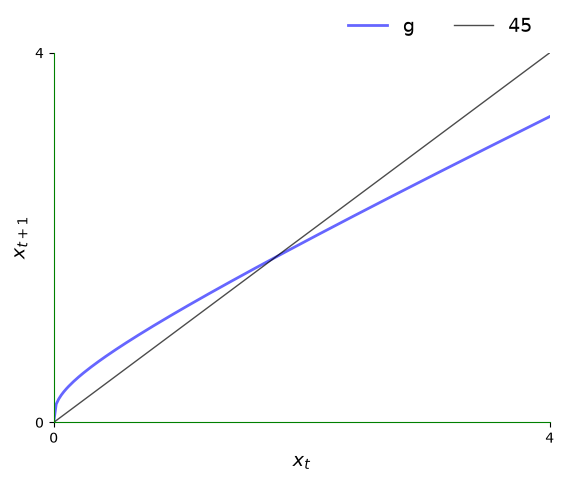

In [4]:
xmin, xmax = 0, 4  # 适合的绘图区域

plot45(g, xmin, xmax, 0, num_arrows=0)

这张图显示了函数 $g$ 和45度线。

可以将 $k_t$ 视为横轴上的一个值。

要计算 $k_{t+1}$，我们可以使用 $g$ 的图像来查看其在纵轴上的值。

显然，

* 如果在这一点上 $g$ 位于45度线之上，那么我们有 $k_{t+1} > k_t$。

* 如果在这一点上 $g$ 位于45度线之下，那么我们有 $k_{t+1} < k_t$。

* 如果在这一点上 $g$ 与45度线相交，那么我们有 $k_{t+1} = k_t$，所以 $k_t$ 是一个稳态。

对于索洛-斯旺模型，当 $S = \mathbb R_+ = [0, \infty)$ 时，有两个稳态。

* 原点 $k=0$

* 唯一的正数，使得 $k = s z k^{\alpha} + (1 - \delta) k$。

通过一些代数运算，我们可以证明在第二种情况下，其稳态是

$$
k^* = \left( \frac{sz}{\delta} \right)^{1/(1-\alpha)}
$$

### 轨迹

根据前面的讨论，在 $g$ 位于45度线之上的区域，我们知道轨迹是递增的。

下图追踪了这样一个区域内的轨迹，使我们能更清楚地看到这一点。

初始条件是 $k_0 = 0.25$。

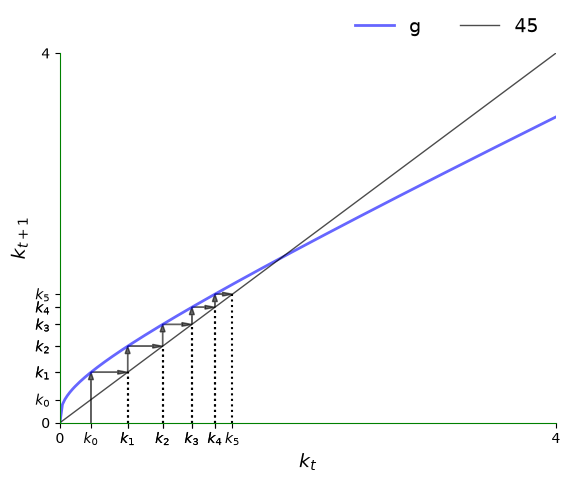

In [5]:
k0 = 0.25

plot45(g, xmin, xmax, k0, num_arrows=5, var='k')

我们可以按照上图所示，绘制人均资本随时间变化的时序图，具体如下：

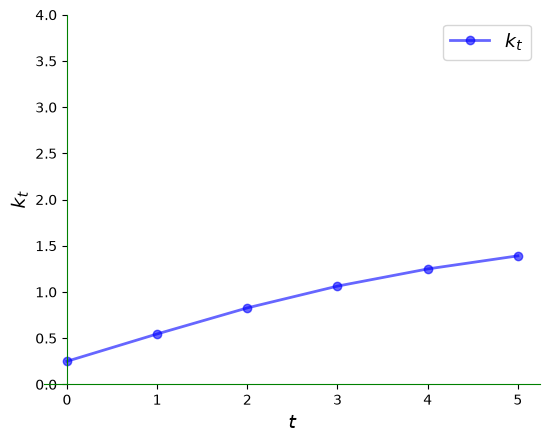

In [6]:
ts_plot(g, xmin, xmax, k0, var='k')

这里是一个稍长期一些的视角：

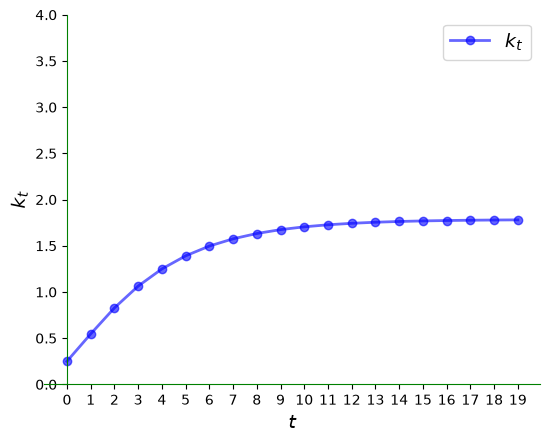

In [7]:
ts_plot(g, xmin, xmax, k0, ts_length=20, var='k')

当人均资本存量高于唯一的正稳态值时，我们可以看到它呈下降趋势：

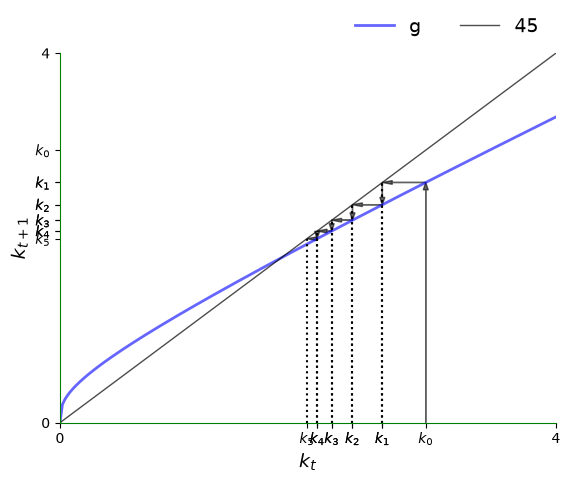

In [8]:
k0 = 2.95

plot45(g, xmin, xmax, k0, num_arrows=5, var='k')

这里是一个时间序列：

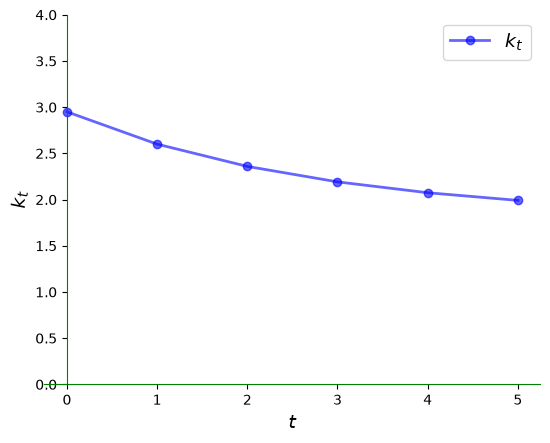

In [9]:
ts_plot(g, xmin, xmax, k0, var='k')

### 复杂动态

索洛-斯旺模型是非线性的，但仍然能生成非常规律的动态。

**二次映射**是一个能生成不规则动态的模型

$$
g(x) = 4 x (1 - x),
\qquad x \in [0, 1]
$$

让我们来看看45度图。

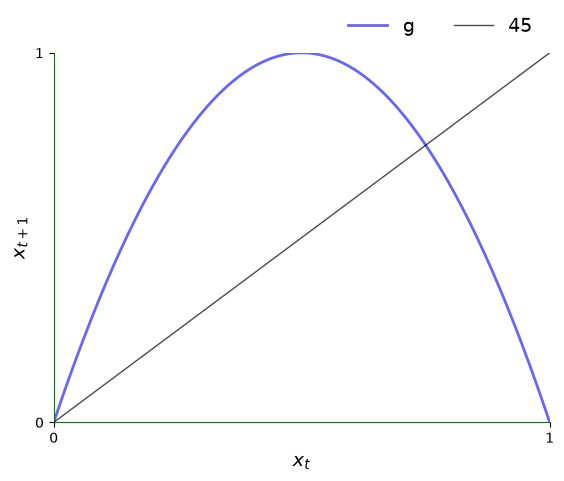

In [10]:
xmin, xmax = 0, 1
g = lambda x: 4 * x * (1 - x)

x0 = 0.3
plot45(g, xmin, xmax, x0, num_arrows=0)

现在让我们来看一个典型的轨迹。

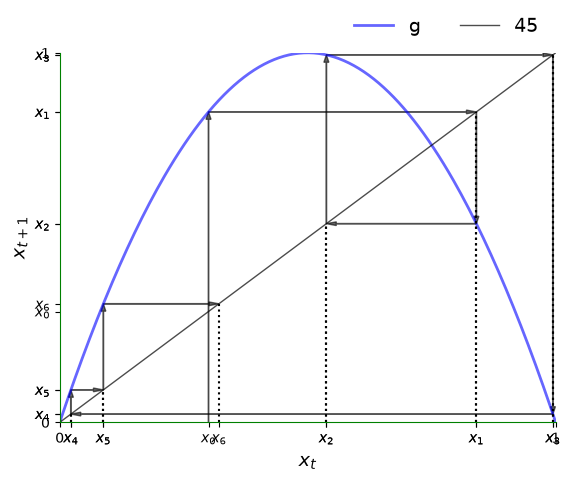

In [11]:
plot45(g, xmin, xmax, x0, num_arrows=6)

注意这个轨迹是多么不规则。

这是相应的时序图。

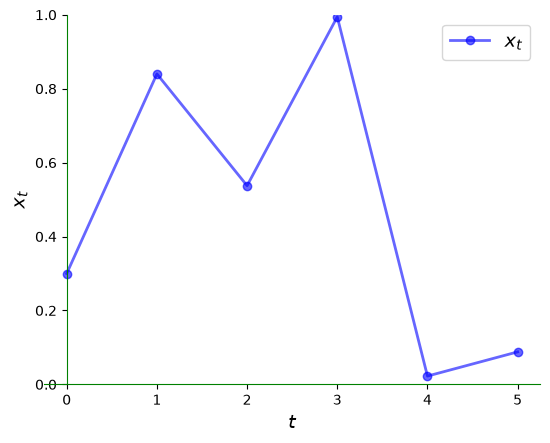

In [12]:
ts_plot(g, xmin, xmax, x0, ts_length=6)

在更长的时间范围内，这种不规则性甚至更加明显：

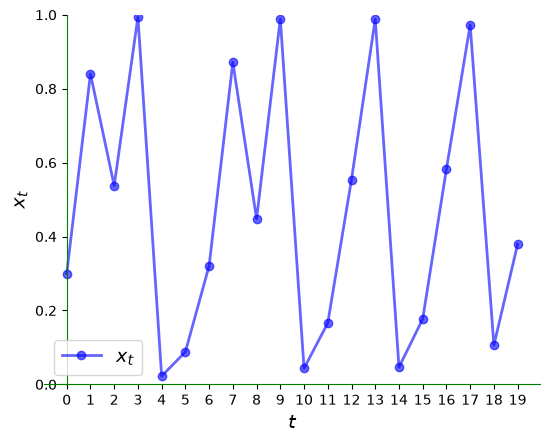

In [13]:
ts_plot(g, xmin, xmax, x0, ts_length=20)

## 练习

```{exercise}
:label: sd_ex1

再次考虑线性模型 $x_{t+1} = a x_t + b$，其中 $a \not=1$。

其唯一的稳态为 $b / (1 - a)$。

当 $|a| < 1$ 时，该稳态是全局稳定的。

请尝试通过考察一系列初始条件，用图形来展示这一点。

在 $a \in (-1, 0)$ 和 $a \in (0, 1)$ 的情况下，你注意到了什么区别？

使用 $a=0.5$ 和 $a=-0.5$ 并分别研究轨迹。

在整个过程中设置 $b=1$。

```

```{solution-start} sd_ex1
:class: dropdown
```

我们将从 $a=0.5$ 的情况开始。

让我们设置模型和绘图区域：

In [14]:
a, b = 0.5, 1
xmin, xmax = -1, 3
g = lambda x: a * x + b

现在让我们来绘制轨迹：

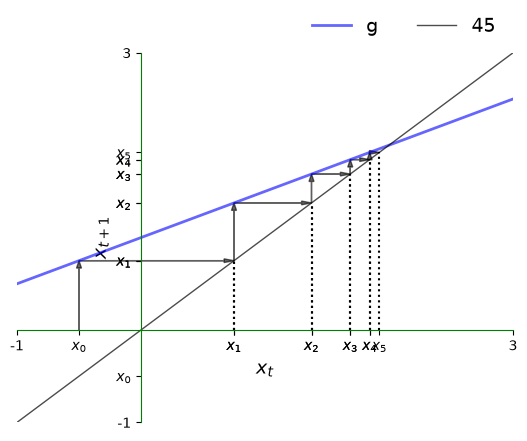

In [15]:
x0 = -0.5
plot45(g, xmin, xmax, x0, num_arrows=5)

这是相应的时间序列，它收敛于稳态。

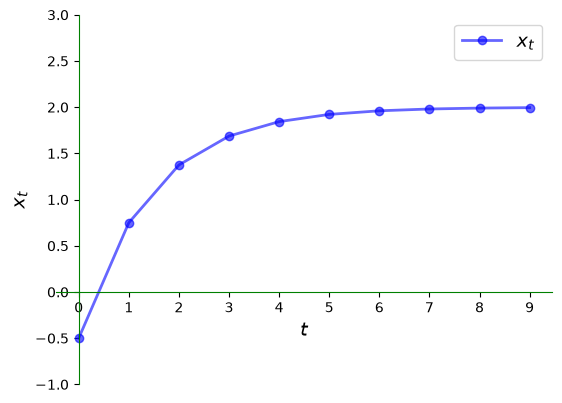

In [16]:
ts_plot(g, xmin, xmax, x0, ts_length=10)

现在让我们尝试 $a=-0.5$ 并观察有什么不同。

我们设置模型和绘图区域为：

In [17]:
a, b = -0.5, 1
xmin, xmax = -1, 3
g = lambda x: a * x + b

现在让我们来绘制轨迹：

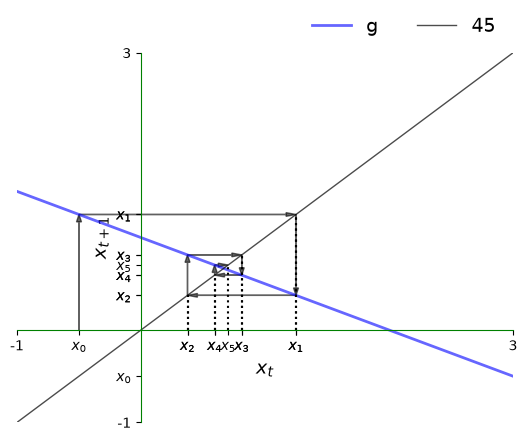

In [18]:
x0 = -0.5
plot45(g, xmin, xmax, x0, num_arrows=5)

以上是相应的时间序列，它收敛于稳态。

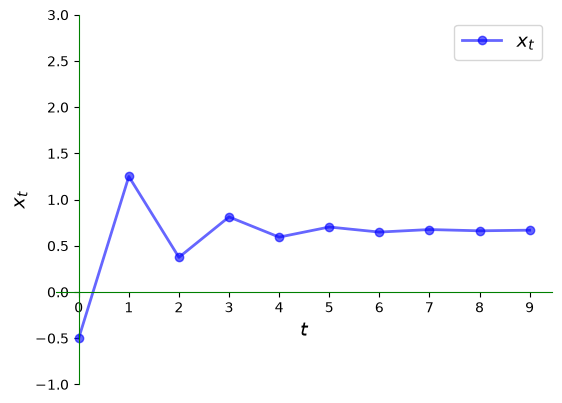

In [19]:
ts_plot(g, xmin, xmax, x0, ts_length=10)

我们同样观察到序列收敛到稳态，但收敛方式明显不同。

特别地，时间序列从稳态上方跳到下方，再跳回来。

在当前情境下，该序列被称为表现出**阻尼振荡**。

```{solution-end}
```